In [55]:
import pandas as pd
import numpy as np
import warnings

import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline, Pipeline

import optuna

import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

%matplotlib inline

In [25]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv', index_col='id')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

In [29]:
train['Churn'] = train['Churn'].map({'Yes' : 1, 'No' : 0})

In [37]:
train.drop_duplicates()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,0
594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,0
594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,0


In [30]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     594194 

In [31]:
train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1


In [32]:
train.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,0.114102,36.577258,65.866223,2494.377057,0.225208
std,0.317936,25.061922,31.067444,2353.916710,0.417719
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,12.000000,29.900000,639.650000,0.000000
50%,0.000000,35.000000,74.100000,1433.650000,0.000000
75%,0.000000,62.000000,90.800000,4263.800000,0.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [33]:
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
num_cols = train.select_dtypes(include=['int64','float64']).columns.tolist()

In [34]:
for col in cat_cols:
    print(train[col].value_counts())

gender
Female    298738
Male      295456
Name: count, dtype: int64
Partner
Yes    309554
No     284640
Name: count, dtype: int64
Dependents
No     414362
Yes    179832
Name: count, dtype: int64
PhoneService
Yes    557893
No      36301
Name: count, dtype: int64
MultipleLines
No                  283384
Yes                 274509
No phone service     36301
Name: count, dtype: int64
InternetService
Fiber optic    272386
DSL            181081
No             140727
Name: count, dtype: int64
OnlineSecurity
No                     289474
Yes                    163993
No internet service    140727
Name: count, dtype: int64
OnlineBackup
No                     250083
Yes                    203384
No internet service    140727
Name: count, dtype: int64
DeviceProtection
No                     247377
Yes                    206090
No internet service    140727
Name: count, dtype: int64
TechSupport
No                     288571
Yes                    164896
No internet service    140727
Name: count, dt

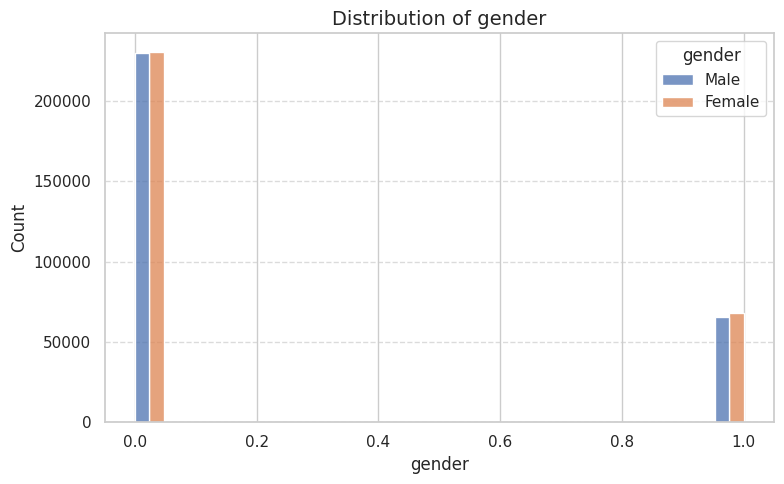

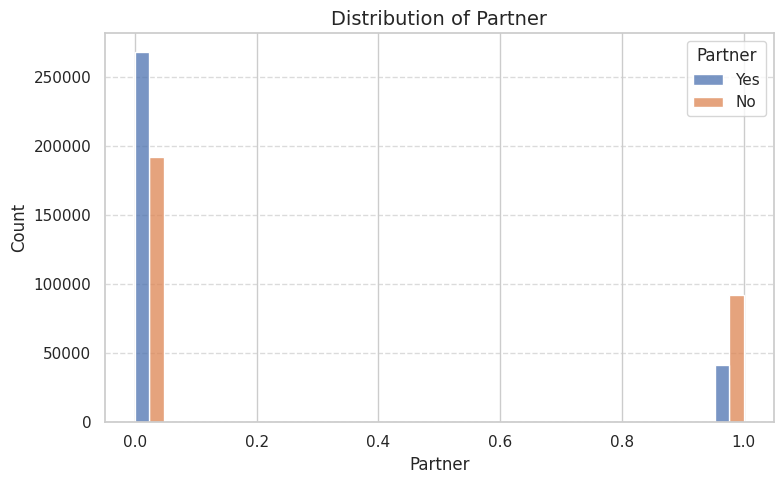

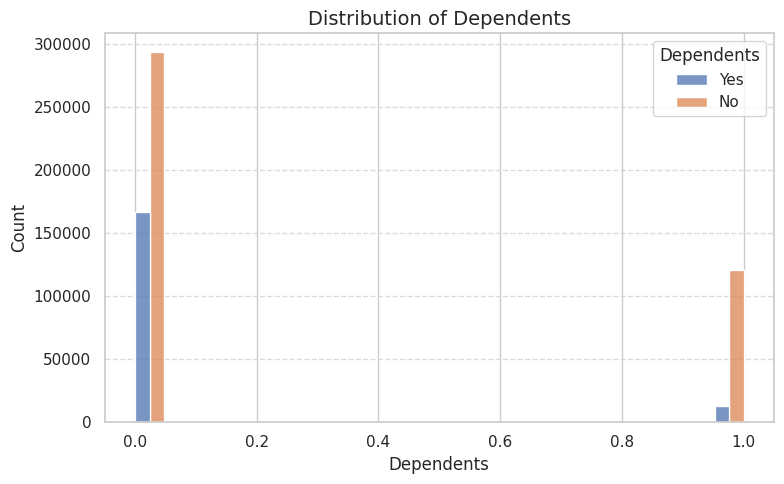

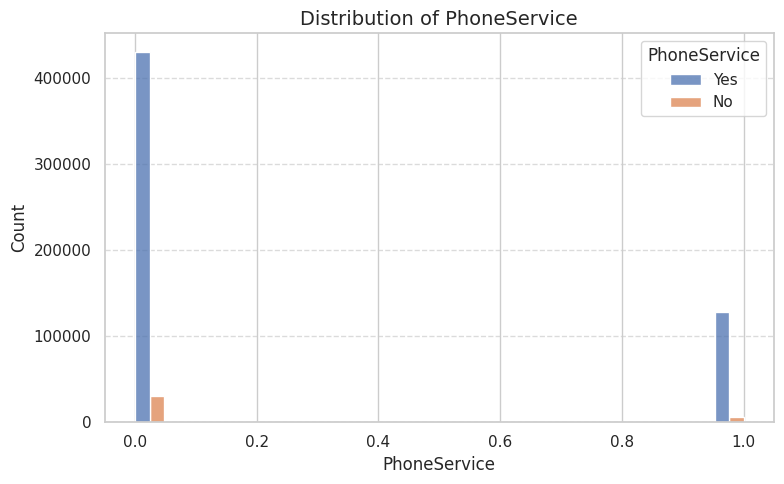

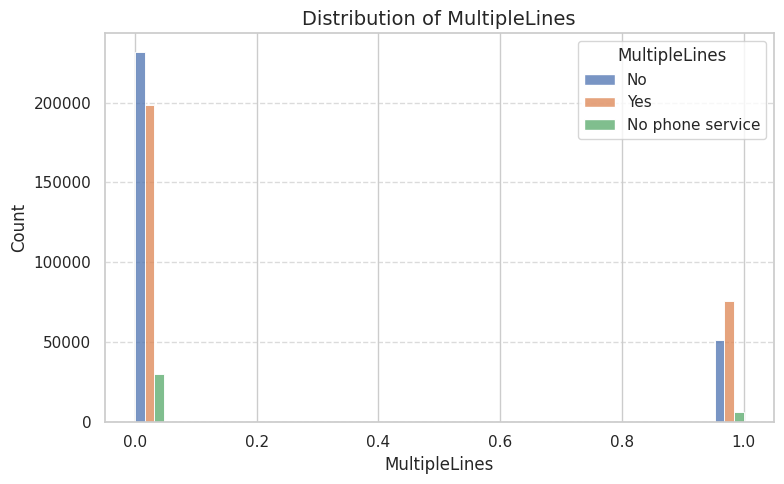

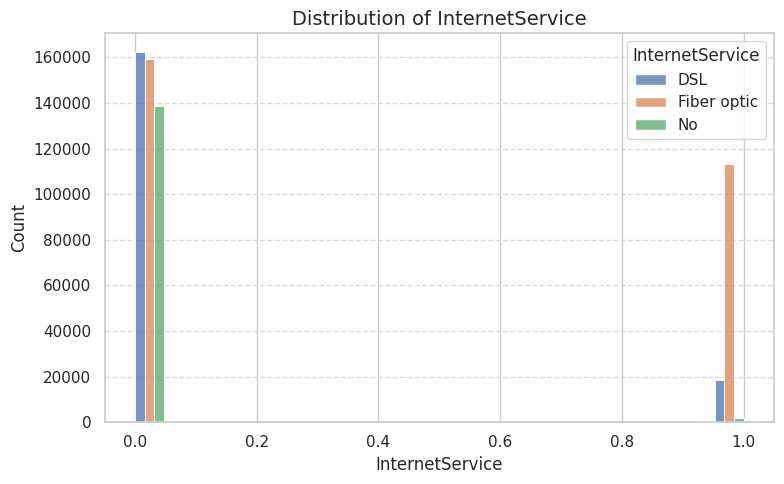

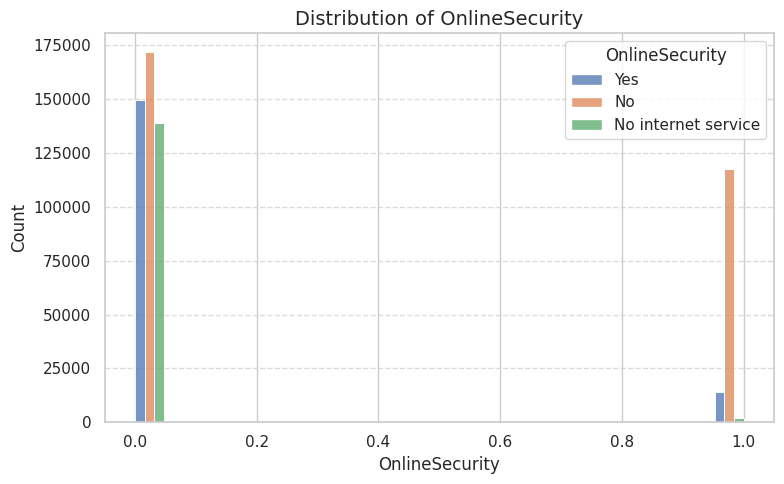

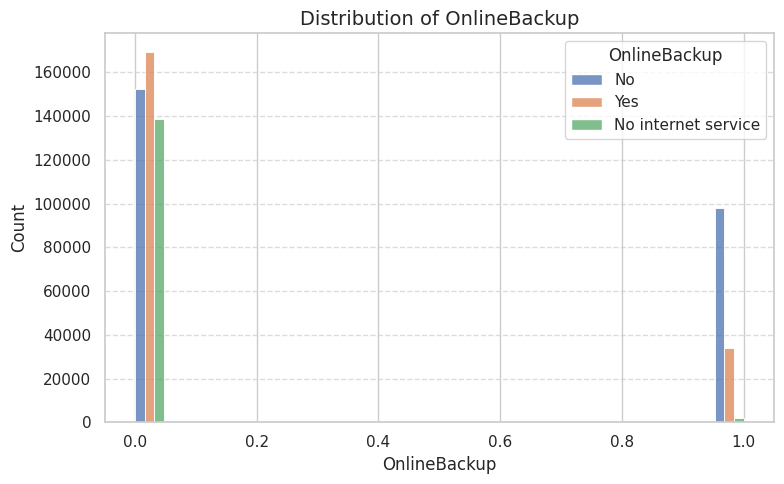

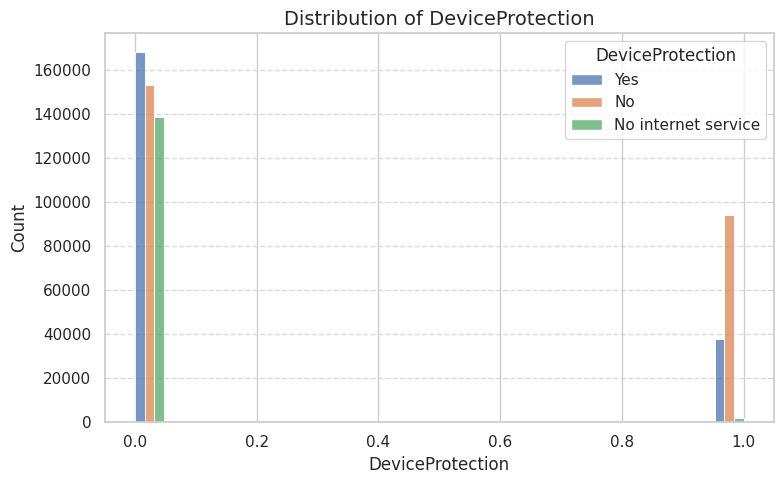

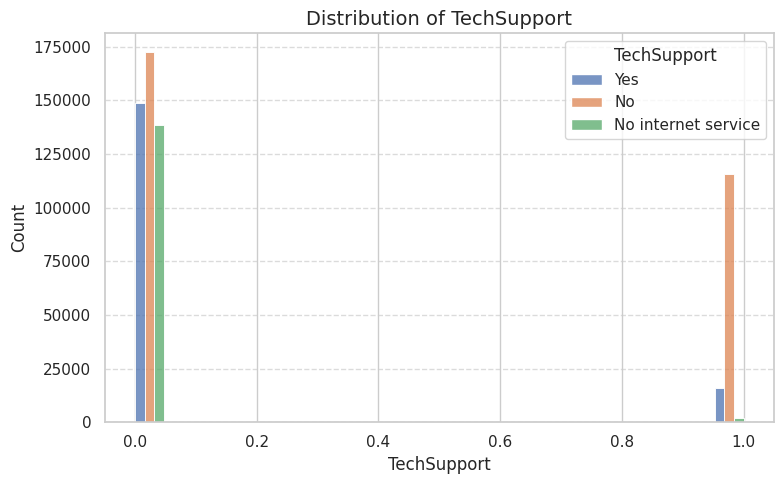

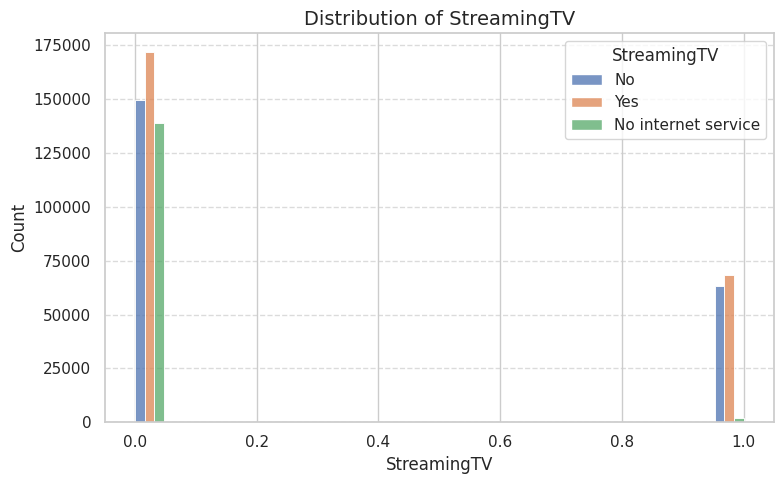

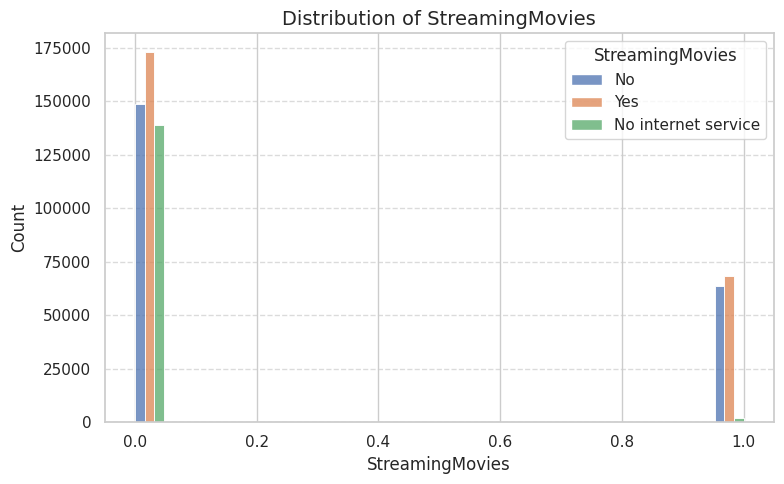

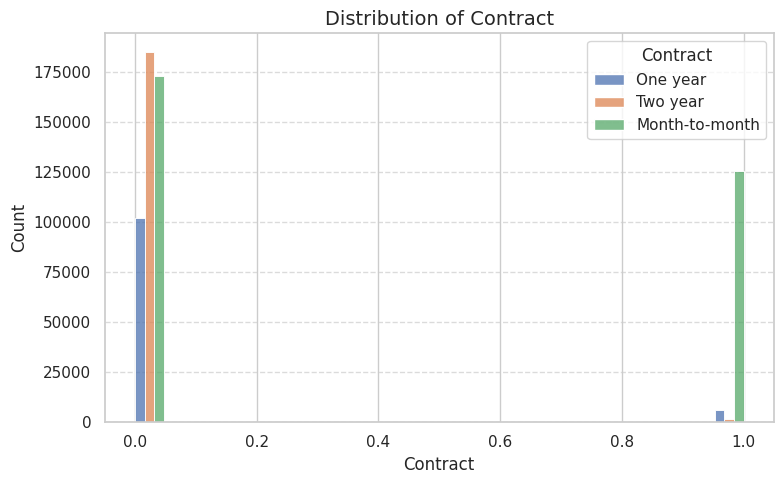

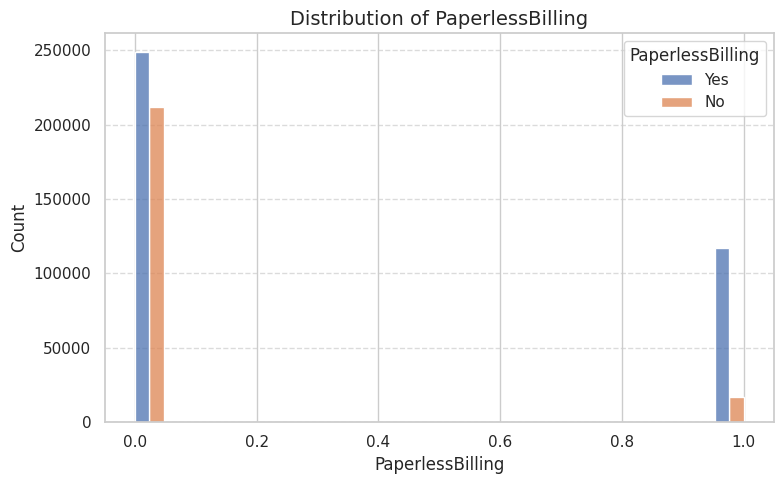

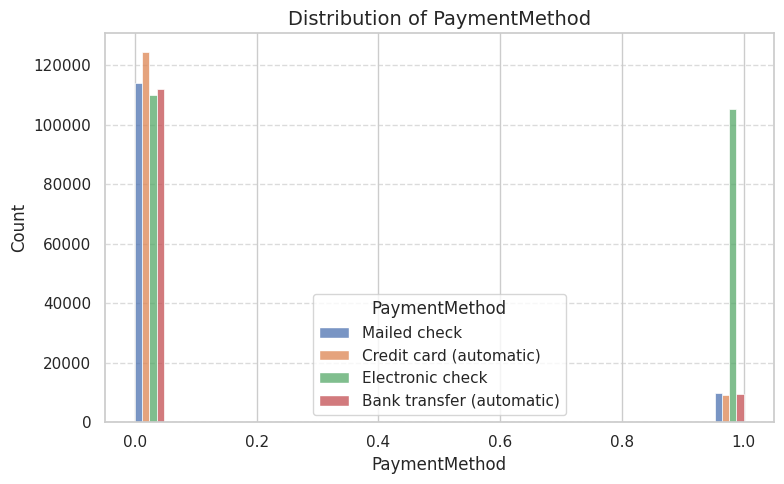

In [35]:
for col in cat_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=train,x='Churn',hue=col,multiple='dodge')
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

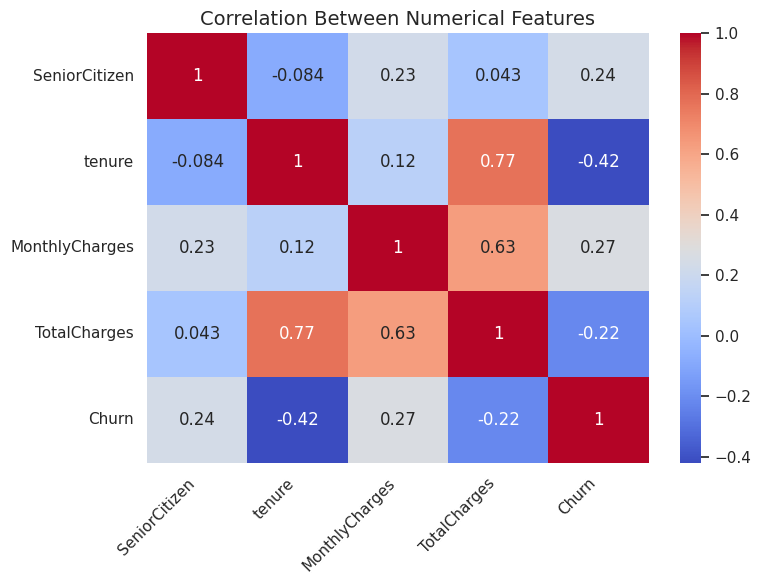

In [36]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    train[num_cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Between Numerical Features", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [40]:
X = train.drop('Churn', axis=1).copy()
y = train['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, shuffle=True, random_state=42)

In [48]:
def column_ratio(X):
    return X[:,[0]]/X[:,[1]]

def ratio_name(function_transformer, feature_names_in):
    return ['ratio']

def ratio_pipeline():
    return make_pipeline(
        SimpleImputer(strategy='median'),
        FunctionTransformer(column_ratio, feature_names_out=ratio_name),
        StandardScaler()
    )
    
cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='error')
)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
)

preprocessor = ColumnTransformer([
    ('cat', cat_pipeline, make_column_selector(dtype_include=object)),
    ('num',default_num_pipeline,make_column_selector(dtype_include=np.number))
    ],
    remainder='passthrough')

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(objective = 'binary',random_state=42,verbose=-1))
])

In [51]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x794789fadf40>),
                                                 ('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x794789fadfd0>)])),
                ('classifier',
                 LGBMClassifier(objective='binary', random_state=42,
                                verbose=-1))])

In [52]:
test_pred = model.predict_proba(X_test)[:,1]
test_labels = (test_pred > 0.5).astype(int)
accuracy = accuracy_score(y_test, test_labels)
roc_auc = roc_auc_score(y_test, test_pred)
print(f'Accuracy: {accuracy}')
print(f'ROC AUC Score: {roc_auc}')
print(classification_report(y_test, test_labels))

Accuracy: 0.861678405237338
ROC AUC Score: 0.9158853591678214
              precision    recall  f1-score   support

           0       0.90      0.93      0.91     91935
           1       0.72      0.64      0.68     26904

    accuracy                           0.86    118839
   macro avg       0.81      0.78      0.79    118839
weighted avg       0.86      0.86      0.86    118839



In [53]:
feature_importances = model['classifier'].feature_importances_
sorted( zip(feature_importances,model['preprocessor'].get_feature_names_out()),reverse=True)

[(np.int32(751), 'num__TotalCharges'),
 (np.int32(615), 'num__tenure'),
 (np.int32(555), 'num__MonthlyCharges'),
 (np.int32(86), 'cat__MultipleLines_Yes'),
 (np.int32(86), 'cat__Contract_Two year'),
 (np.int32(86), 'cat__Contract_One year'),
 (np.int32(80), 'num__SeniorCitizen'),
 (np.int32(75), 'cat__OnlineSecurity_Yes'),
 (np.int32(72), 'cat__PaperlessBilling_Yes'),
 (np.int32(69), 'cat__InternetService_Fiber optic'),
 (np.int32(67), 'cat__StreamingTV_Yes'),
 (np.int32(62), 'cat__Dependents_Yes'),
 (np.int32(57), 'cat__PaymentMethod_Electronic check'),
 (np.int32(55), 'cat__StreamingMovies_Yes'),
 (np.int32(44), 'cat__TechSupport_Yes'),
 (np.int32(43), 'cat__PhoneService_Yes'),
 (np.int32(36), 'cat__OnlineBackup_Yes'),
 (np.int32(33), 'cat__InternetService_No'),
 (np.int32(30), 'cat__DeviceProtection_Yes'),
 (np.int32(24), 'cat__gender_Male'),
 (np.int32(21), 'cat__PaymentMethod_Credit card (automatic)'),
 (np.int32(21), 'cat__MultipleLines_No phone service'),
 (np.int32(16), 'cat__P

In [56]:
def objective(trial):
    params = {
    'classifier__n_estimators': trial.suggest_int('n_estimators', 200, 600),
    'classifier__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
    'classifier__num_leaves': trial.suggest_int('num_leaves', 31, 128),
    'classifier__min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
    'classifier__reg_alpha': trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
    'classifier__reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
    'classifier__colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 0.9),
}
    
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', lgb.LGBMClassifier(objective='binary', random_state=42))
    ])
    
    model.set_params(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best trial params:", study.best_trial.params)

best_lgm = Pipeline([
    ('preprocessor', preprocessing),
    ('classifier', lgb.LGBMClassifier(objective='binary', random_state=42,verbose=-1))
])

best_params = {f'classifier__{k}': v for k, v in study.best_trial.params.items()}
best_lgm.set_params(**best_params)
best_lgm.fit(X_train, y_train)

[I 2026-03-18 19:40:19,410] A new study created in memory with name: no-name-5978c23c-eb7b-4da6-aa0a-9bbec9beb3d7
[I 2026-03-18 19:41:36,499] Trial 0 finished with value: 0.9155956134806503 and parameters: {'n_estimators': 599, 'learning_rate': 0.027326072893628883, 'num_leaves': 62, 'min_child_samples': 45, 'reg_alpha': 0.19288559846100062, 'reg_lambda': 1.8625423011353106, 'colsample_bytree': 0.83875690376756}. Best is trial 0 with value: 0.9155956134806503.
[I 2026-03-18 19:42:21,897] Trial 1 finished with value: 0.9133534344650179 and parameters: {'n_estimators': 260, 'learning_rate': 0.010152651468608196, 'num_leaves': 73, 'min_child_samples': 98, 'reg_alpha': 0.7755039496746949, 'reg_lambda': 6.4535894463746875, 'colsample_bytree': 0.8730498958667843}. Best is trial 0 with value: 0.9155956134806503.
[I 2026-03-18 19:43:21,307] Trial 2 finished with value: 0.9155398868695946 and parameters: {'n_estimators': 364, 'learning_rate': 0.034273015082774805, 'num_leaves': 91, 'min_child_s

Best trial params: {'n_estimators': 600, 'learning_rate': 0.05771572113916509, 'num_leaves': 44, 'min_child_samples': 35, 'reg_alpha': 8.528084908704592, 'reg_lambda': 4.629118190955162, 'colsample_bytree': 0.6311258621680353}


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7947aefd80e0>),
                                                 ('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImput...
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7947aefdb380>)])),
                ('classifier',
                 LGBMClassifier(colsample_bytree=0.6311258621680353,
                                learning_rate=0.05771572113916509,
                                min_child_samples=35, n_estimators=600,
                                num_leaves=44, objective='binary',
                                random_state=42, reg_alpha=8.528084908704592,
                                reg_lambda=4.629118190955162, verbose=-1))])

In [57]:
train_auc = roc_auc_score(y_train, best_lgm.predict_proba(X_train)[:, 1])
val_auc = study.best_value 

print(f"Training AUC: {train_auc:.4f}")
print(f"Validation AUC: {val_auc:.4f}")

Training AUC: 0.9198
Validation AUC: 0.9160


In [59]:
submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')
submission['Churn'] = best_lgm.predict_proba(test)[:,1]
submission[['id','Churn']].to_csv("submission.csv", index=False)